In [26]:
import h5py as h5 

import matplotlib.pyplot as plt
from matplotlib import cm, colors
import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm
from matplotlib import colors, ticker

import numpy as np
import os, sys
import traceback

import h5flow 
plt.style.use('../../utils/dune.mplstyle')
from sklearn.cluster import DBSCAN 

# Path to repo root (two directories above notebook)
light_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(light_root)

from light.PMT_analysis_utils import * 

# Path to repo root (two directories above notebook)
repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(repo_root)

from utils.backtracking import get_charge_event_hits, hit_backtracker, get_ancestry # Now this works
from utils.my_ev_display import event_display

In [27]:
# Configure your analysis here 
# This debug mode will process only the 10% of the dataset , use this if looking at source data
DEBUG = False

#input_dataset = "/global/cfs/cdirs/dune/www/data/2x2/reflows_run2/v0/flow/ColdOperations/data/2025_Operations_Cold/source/AmBe_1112"
#input_dataset = "/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin2/one_trig_32us_window"
#input_dataset = "/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin0/mod2_pmt_trig"
input_dataset = "/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source"

MULTI = False

out_clusters = "../output/source_ambe_bin2_one_trig_32us_window_clusters.csv"

In [ ]:
def filter_hits(hits_set):
    # Remove hits with negative energy
    hits_set = hits_set[hits_set[:,3] > 0.]
    # Remove hits with any NaN field
    hits_set = hits_set[~np.isnan(hits_set).any(axis=1)]
    return hits_set 

In [29]:
def CL_AmBe_analysis(input_file,file_id,single=True):
    h5_file = h5flow.data.H5FlowDataManager(input_file,'r')
    g_triggers = None
    b_triggers = None

    # Initialize output dataset 
    out_dataset = {
        "clusters":None
    }

    if(single):
        g_triggers, b_triggers = classify_triggers_single(h5_file,debug=False)
    
    else: 
        first_trig = check_first_trig(h5_file,291)
        parity_str = None
        if(first_trig):
            parity_str = "odd"
        else:
            parity_str = "even"
        print(f"Parity of this file: {parity_str}")
        g_triggers, b_triggers = classify_triggers(h5_file,parity_str,debug=False)

    #print(f"List of good triggers: {g_triggers}")

    # Retrieve products linked to good triggers 
    light_events = h5_file['light/events',g_triggers]
    light_wvfms = h5_file['light/wvfm',g_triggers]
    charge_events = h5_file['light/events','charge/events',g_triggers]
    charge_hits = h5_file['light/events','charge/events','charge/calib_prompt_hits',g_triggers]

    # Charge
    non_zero_charge_hits = charge_hits[charge_events.data['nhit'][:,0] >= 1]
    non_zero_charge_events = charge_events[charge_events.data['nhit'][:,0] >= 1]
    non_zero_charge_light_ev = light_events[charge_events.data['nhit'][:,0] >= 1] 

    E_clusters = []
    n_cluster = [] 
    n_hits_clusters = [] 
    cluster_light_ev_id = [] 

    clusterized_hits = [] 

    db = DBSCAN(eps=3,min_samples=2)
    for icharge in range(len(non_zero_charge_events)):
    #for icharge in range(2):
        test_event_hits = non_zero_charge_hits[:,0][icharge][0:non_zero_charge_events.data['nhit'][:,0][icharge]]
        this_event_light_id = non_zero_charge_light_ev['id'][icharge]
        hits_stack_unfiltered = np.column_stack((test_event_hits.data['x'],test_event_hits.data['y'],test_event_hits.data['z'],test_event_hits.data['E'],np.ones(len(test_event_hits))*this_event_light_id))
        hits_stack = filter_hits(hits_stack_unfiltered)
        if(len(hits_stack)==0):
            continue
        labels = db.fit_predict(hits_stack[:,:3])
        hits_stack_label = np.column_stack((hits_stack[:,0],hits_stack[:,1],hits_stack[:,2],hits_stack[:,3],np.ones(len(hits_stack))*int(this_event_light_id),labels,np.ones(len(hits_stack))*int(file_id)))
        clusterized_hits.extend(hits_stack_label.tolist())
        temp_n_clusters = 0

        for l in np.unique(labels):
            if(l!=-1):
                this_l_hits = hits_stack_label[hits_stack_label[:,5]==l]
                n_hits_clusters.append(len(this_l_hits))
                E_clusters.append(np.sum(this_l_hits[:,3]))
                cluster_light_ev_id.append([l,this_event_light_id])
                temp_n_clusters+=1
            else:
                continue
        n_cluster.append(temp_n_clusters)

    out_dataset["clusters"] = clusterized_hits


    return out_dataset


In [30]:
all_clusters = []

for file_count, ifile in enumerate(os.listdir(input_dataset)):

    # Run over 10% of the dataset
    if DEBUG and file_count >= int(len(os.listdir(input_dataset))*0.1):
        break

    this_file = os.path.join(input_dataset, ifile)
    print(this_file)

    try:
        temp_out = CL_AmBe_analysis(
            this_file,
            file_count,
            single=not MULTI
        )
        all_clusters.extend(temp_out["clusters"])

    except Exception as e:
        print(f"[WARNING] Failed processing {this_file}: {e}")
        continue



/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p44_v0p2.FLOW.hdf5
Running with all the 1613 events
Fraction of good triggers 0.1500309981401116
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p61_v0p2.FLOW.hdf5
Running with all the 1583 events
Fraction of good triggers 0.15666456096020215
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p67_v0p2.FLOW.hdf5
Running with all the 1572 events
Fraction of good triggers 0.15966921119592875
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p69_v0p2.FLOW.hdf5
Running with all the 1653 events
Fraction of good triggers 0.1500302480338778
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_t

/pscratch/sd/l/lmlepin/clean_repo/2x2_neutron_sources/AmBe/light/PMT_analysis_utils.py:232: RuntimeWarning: divide by zero encountered in divide
  fprompt_mask = ((fast_light/all_light) > fprompt_min)*((fast_light/all_light) < fprompt_max)


Fraction of good triggers 0.16273442226255294
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p43_v0p2.FLOW.hdf5
Running with all the 1610 events
Fraction of good triggers 0.17888198757763976
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p68_v0p2.FLOW.hdf5
Running with all the 1643 events


/pscratch/sd/l/lmlepin/clean_repo/2x2_neutron_sources/AmBe/light/PMT_analysis_utils.py:232: RuntimeWarning: divide by zero encountered in divide
  fprompt_mask = ((fast_light/all_light) > fprompt_min)*((fast_light/all_light) < fprompt_max)


Fraction of good triggers 0.16189896530736458
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p24_v0p2.FLOW.hdf5
Running with all the 1590 events
Fraction of good triggers 0.1610062893081761
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p18_v0p2.FLOW.hdf5
Running with all the 1560 events
Fraction of good triggers 0.15897435897435896
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p8_v0p2.FLOW.hdf5
Running with all the 1606 events
Fraction of good triggers 0.16749688667496887
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p50_v0p2.FLOW.hdf5
Running with all the 1595 events


/pscratch/sd/l/lmlepin/clean_repo/2x2_neutron_sources/AmBe/light/PMT_analysis_utils.py:232: RuntimeWarning: divide by zero encountered in divide
  fprompt_mask = ((fast_light/all_light) > fprompt_min)*((fast_light/all_light) < fprompt_max)


Fraction of good triggers 0.14231974921630094
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p5_v0p2.FLOW.hdf5
Running with all the 1677 events
Fraction of good triggers 0.16756112104949314
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p11_v0p2.FLOW.hdf5
Running with all the 1662 events
Fraction of good triggers 0.1588447653429603
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p36_v0p2.FLOW.hdf5
Running with all the 1673 events
Fraction of good triggers 0.16557083084279736
/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p29_v0p2.FLOW.hdf5
Running with all the 1732 events
Fraction of good triggers 0.17263279445727484
/pscratch/sd/d/dunepro/mkramer/output/Reflow

In [31]:
all_clusters_array = np.array(all_clusters)

In [32]:
CAPTURE_HIT_CUT = 4
for ifile in np.unique(all_clusters_array[:,6]):
    
    print(f"Dimensions of file {ifile} {all_clusters_array[all_clusters_array[:,6]==ifile].shape}")


Dimensions of file 0.0 (658, 7)
Dimensions of file 1.0 (625, 7)
Dimensions of file 2.0 (653, 7)
Dimensions of file 3.0 (1218, 7)
Dimensions of file 4.0 (558, 7)
Dimensions of file 5.0 (653, 7)
Dimensions of file 6.0 (1031, 7)
Dimensions of file 7.0 (684, 7)
Dimensions of file 8.0 (732, 7)
Dimensions of file 9.0 (669, 7)
Dimensions of file 10.0 (796, 7)
Dimensions of file 11.0 (633, 7)
Dimensions of file 12.0 (662, 7)
Dimensions of file 13.0 (706, 7)
Dimensions of file 14.0 (521, 7)
Dimensions of file 15.0 (803, 7)
Dimensions of file 16.0 (622, 7)
Dimensions of file 17.0 (702, 7)
Dimensions of file 18.0 (713, 7)
Dimensions of file 19.0 (846, 7)


In [33]:
import pandas as pd

df = pd.DataFrame(all_clusters_array, columns=[f"c{i}" for i in range(7)])

df["id"] = (
    df["c6"].astype(str)
    + "::" + df["c4"].astype(str)
    + "::" + df["c5"].astype(str)
)

df.to_csv(out_clusters)

In [34]:
df.head()

,c0,c1,c2,c3,c4,c5,c6,id
0,-53.394413,-56.062389,38.349686,0.816514,0.0,-1.0,0.0,0.0::0.0::-1.0
1,29.921331,60.524101,42.146301,0.315671,13.0,0.0,0.0,0.0::13.0::0.0
2,30.112905,60.524101,42.589699,0.148954,13.0,0.0,0.0,0.0::13.0::0.0
3,-35.625897,-60.524101,-58.108700,0.394033,13.0,-1.0,0.0,0.0::13.0::-1.0
4,-59.604614,-18.844500,-38.599098,0.415220,13.0,-1.0,0.0,0.0::13.0::-1.0


In [35]:
unique_cluster_ids = np.unique(df['id'])
print(unique_cluster_ids)

['0.0::0.0::-1.0' '0.0::1021.0::-1.0' '0.0::103.0::-1.0' ...
 '9.0::991.0::-1.0' '9.0::997.0::-1.0' '9.0::998.0::0.0']


In [36]:
n_hits_cluster = []
E_capture_like = []
E_inelastitc_like = [] 


for icluster in unique_cluster_ids:
    sub_df = df[df['id']==icluster]
    n_hits_cluster.append(len(sub_df))

    if(len(sub_df)>=4 and np.sum(sub_df['c3']>2.)):
        E_capture_like.append(np.sum(sub_df['c3']))

    if(len(sub_df)==2):
        E_inelastitc_like.append(np.sum(sub_df['c3']))

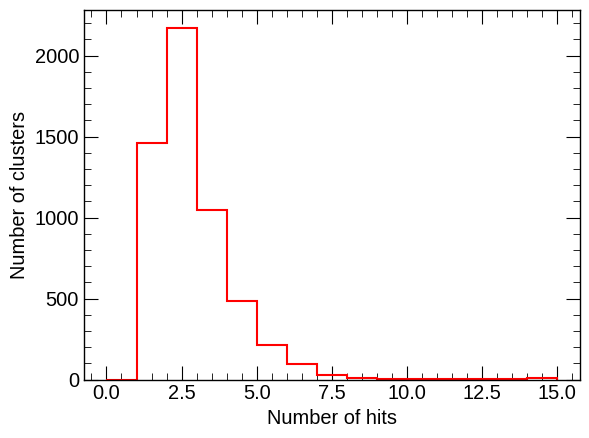

In [37]:
plt.hist(n_hits_cluster,bins=np.linspace(0,15,16),color='red',histtype='step')
plt.xlabel("Number of hits")
plt.ylabel("Number of clusters")
plt.show()

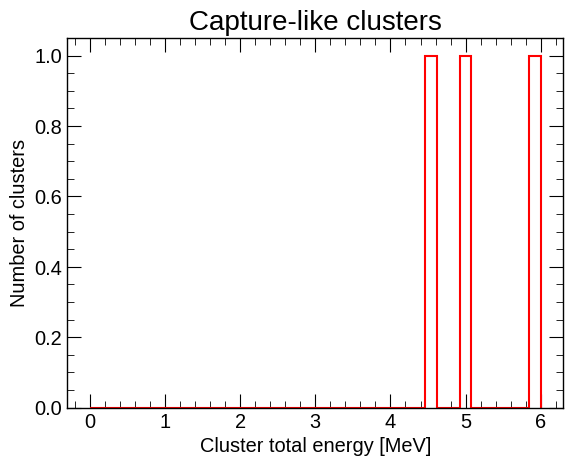

In [38]:
plt.hist(E_capture_like,bins=np.linspace(0,6,40),histtype='step',color='red')
plt.title("Capture-like clusters")
plt.xlabel("Cluster total energy [MeV]")
plt.ylabel("Number of clusters")
plt.show()

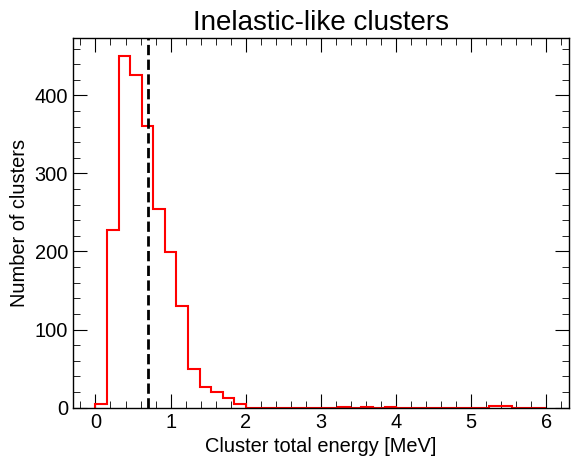

In [39]:
plt.hist(E_inelastitc_like,bins=np.linspace(0,6,40),histtype='step',color='red')
plt.title("Inelastic-like clusters")
plt.xlabel("Cluster total energy [MeV]")
plt.ylabel("Number of clusters")
plt.axvline(x=0.7,ls="--")
plt.show()